# M* — How Many Probes Does the Local Rule Actually Need?

**Where this fits:** the last two notebooks measured *architecture* — is a model's structure clean (independent channels) or tangled? Diffusion's core denoiser came back exactly clean (coupling density 0.000). That answered "is this model *usable* by the local rule at all." It did **not** answer "is the local rule actually *cheaper* than backprop."

That second question depends on a number the barrier law names explicitly but that hasn't been measured yet: **M\*** — how many probe samples the three-factor Hebbian rule needs, per update, to get a gradient estimate that's actually pointing in a good direction.

**This notebook measures M\* directly, for two feedback strategies:**
- **K=1 (global scalar):** one shared random probe direction, one shared score (the total loss across all channels) broadcast to update every channel. This is the expensive, "one grade for the whole class" case.
- **K=C (per-channel):** the same random probe direction, but each channel reads its *own* private loss to compute its *own* score. This only works because the model is diagonal (zero cross-channel coupling, confirmed in the previous notebook) — that's precisely what makes it possible to extract C independent, clean scores out of a *single* forward pass, instead of one noisy shared score.

**Then it converts M\* into an actual cost comparison against backpropagation** — the number this whole line of experiments has been building toward.

## Step 0 — Setup

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

Using device: cuda


## Config

- `C` = number of spectral modes / channels (same as the previous two notebooks, for continuity).
- `B` = batch size for the regression task used to define the loss.
- `SIGMA` = probe perturbation size.
- `COS_THRESHOLD` = the "good enough" gradient-alignment bar used to define M*.
- `BACKWARD_COST_MULTIPLIER` = a standard rule-of-thumb assumption that a backward pass costs roughly 2× a forward pass in FLOPs, so one full backprop step costs about 1 + 2 = 3 forward-pass-equivalents. This is a widely used approximation, not something derived in this notebook — flagged explicitly so the final cost comparison's assumptions are visible, not hidden.

In [ ]:
C = 8
B = 64
SIGMA = 0.05
COS_THRESHOLD = 0.9
BACKWARD_COST_MULTIPLIER = 2.0   # backward pass ≈ 2x a forward pass, in FLOPs (standard rule of thumb)

## Step 1 — The task: the confirmed-clean spectral gain bank, made trainable

This is the exact architecture that scored 0.000 coupling density in the previous notebook: each mode `k` has its own gain `R_k`, applied as `y_k = R_k * x_k`. Here it's wired up as an actual regression task — a synthetic "true" gain `R_true` generates clean targets, and we start from a random initial guess `R0`, so there's a real, nonzero gradient to estimate and compare against.

In [ ]:
R_true = (torch.rand(C, device=device) * 1.0 + 0.5)     # the gains we're trying to recover
x = torch.randn(B, C, device=device)                     # fixed regression inputs
y = x * R_true                                           # noiseless targets
R0 = torch.randn(C, device=device) * 0.3 + 1.0            # initial guess, away from R_true

def per_mode_loss(R):
    """R: (..., C) -> per-mode MSE loss, (..., C). Never mixes channels -- matches the
    confirmed-diagonal architecture exactly."""
    pred = x * R.unsqueeze(-2)          # broadcasts to (..., B, C)
    return ((pred - y) ** 2).mean(dim=-2)  # mean over batch -> (..., C)

def total_loss(R):
    return per_mode_loss(R).sum(dim=-1)

## Step 2 — Ground truth: the exact gradient via autograd

This is our reference, not something being tested. Ordinary backprop gives us the exact gradient to compare probe-based estimates against.

In [ ]:
R0_grad = R0.clone().requires_grad_(True)
loss = total_loss(R0_grad)
loss.backward()
true_grad = R0_grad.grad.detach().clone()
print('True gradient:', true_grad.cpu().numpy().round(4))

True gradient: [ 1.7544 -0.3777  0.7095 -0.6636 -0.7426 -0.8725  0.8453 -0.1286]


## Step 3 — The two probe-based estimators

Both use the identical antithetic (central-difference) three-factor rule from your proposal:

`g_hat = xi * (L(theta + sigma*xi) - L(theta - sigma*xi)) / (2*sigma)`

The *only* difference between K=1 and K=C is which loss `L` feeds the score:
- **K=1:** `L` is the total loss (summed across all channels) — one shared score updates every channel via the same broadcast value.
- **K=C:** `L` is each channel's own private loss — each channel gets its own score, computed from its own residual only.

Both are fully vectorized: because the model never mixes channels, all C channels' antithetic pairs can be computed in a single forward pass, for every probe, regardless of which strategy is used. **This means K=C is not more expensive per probe than K=1** — it's the same 2 forward passes per probe either way. The only thing that differs is how many probes (M) each strategy needs to reach a good estimate, which is exactly what we're about to measure.

In [ ]:
def estimate_gradients(R, M, n_repeats, mode):
    """
    R: (C,) current parameters
    M: probes averaged per gradient estimate
    n_repeats: independent repeats, to get mean/std of alignment
    mode: 'K1' (global scalar) or 'KC' (per-channel scalar)
    Returns: (n_repeats, C) tensor of estimated gradient vectors.
    """
    C = R.shape[0]
    ests = []
    for _ in range(n_repeats):
        xi = torch.randn(M, C, device=R.device)
        Rp = R.unsqueeze(0) + SIGMA * xi     # (M, C)
        Rm = R.unsqueeze(0) - SIGMA * xi
        Lp = per_mode_loss(Rp)               # (M, C) -- per-channel losses, never summed yet
        Lm = per_mode_loss(Rm)
        if mode == 'KC':
            score = (Lp - Lm) / (2 * SIGMA)          # (M, C) -- each channel's own score
            g = xi * score
        else:  # 'K1'
            Lp_tot = Lp.sum(dim=-1, keepdim=True)     # (M, 1) -- one shared score
            Lm_tot = Lm.sum(dim=-1, keepdim=True)
            score = (Lp_tot - Lm_tot) / (2 * SIGMA)
            g = xi * score                            # broadcast to all channels
        ests.append(g.mean(dim=0))                    # average over the M probes
    return torch.stack(ests)                          # (n_repeats, C)

def cosine_to_true(est, true_grad):
    est = est.detach()
    num = (est * true_grad).sum(dim=-1)
    den = est.norm(dim=-1) * true_grad.norm() + 1e-12
    return num / den

## Step 4 — Sweep M, measure alignment, find M*

In [ ]:
Ms = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
N_REPEATS = 20

rows = []
mstar = {'K1': None, 'KC': None}
for M in Ms:
    est_k1 = estimate_gradients(R0, M, N_REPEATS, 'K1')
    est_kc = estimate_gradients(R0, M, N_REPEATS, 'KC')
    cos_k1 = cosine_to_true(est_k1, true_grad)
    cos_kc = cosine_to_true(est_kc, true_grad)
    row = (M, cos_k1.mean().item(), cos_k1.std().item(), cos_kc.mean().item(), cos_kc.std().item())
    rows.append(row)
    if mstar['K1'] is None and row[1] >= COS_THRESHOLD:
        mstar['K1'] = M
    if mstar['KC'] is None and row[3] >= COS_THRESHOLD:
        mstar['KC'] = M

print(f"{'M':>6s} {'K=1 cos':>10s} {'K=1 std':>10s} {'K=C cos':>10s} {'K=C std':>10s}")
print('-' * 55)
for M, m1, s1, mc, sc in rows:
    print(f'{M:6d} {m1:10.3f} {s1:10.3f} {mc:10.3f} {sc:10.3f}')

print()
print(f"M* (K=1, cosine >= {COS_THRESHOLD}):", mstar['K1'] if mstar['K1'] else f'not reached by M={Ms[-1]}')
print(f"M* (K=C, cosine >= {COS_THRESHOLD}):", mstar['KC'] if mstar['KC'] else f'not reached by M={Ms[-1]}')

     M    K=1 cos    K=1 std    K=C cos    K=C std
-------------------------------------------------------
     1      0.217      0.164      0.660      0.177
     2      0.329      0.184      0.777      0.120
     5      0.610      0.143      0.898      0.078
    10      0.689      0.149      0.923      0.056
    20      0.840      0.070      0.965      0.028
    50      0.933      0.030      0.986      0.010
   100      0.968      0.019      0.993      0.005
   200      0.986      0.007      0.996      0.003
   500      0.992      0.005      0.999      0.001
  1000      0.997      0.001      0.999      0.001

M* (K=1, cosine >= 0.9): 50
M* (K=C, cosine >= 0.9): 10


## Step 5 — Plot: alignment vs. probe budget

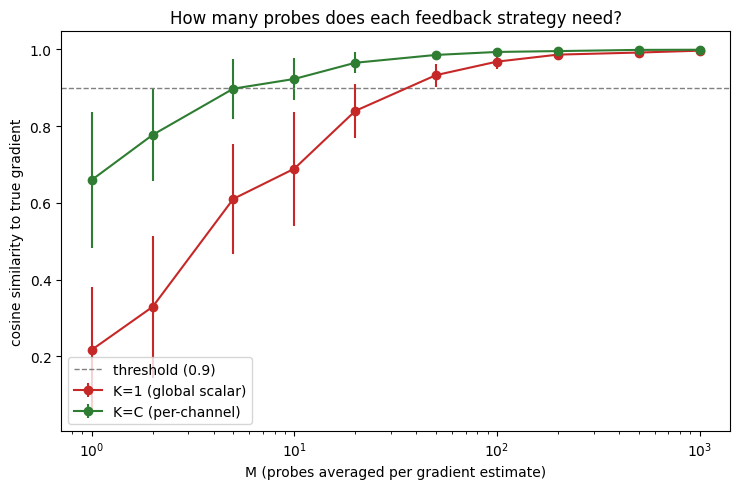

In [ ]:
Ms_arr = [r[0] for r in rows]
m1_mean = [r[1] for r in rows]; m1_std = [r[2] for r in rows]
mc_mean = [r[3] for r in rows]; mc_std = [r[4] for r in rows]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.errorbar(Ms_arr, m1_mean, yerr=m1_std, marker='o', label='K=1 (global scalar)', color='#C62828')
ax.errorbar(Ms_arr, mc_mean, yerr=mc_std, marker='o', label='K=C (per-channel)', color='#2E7D32')
ax.axhline(COS_THRESHOLD, color='gray', linestyle='--', linewidth=1, label=f'threshold ({COS_THRESHOLD})')
ax.set_xscale('log')
ax.set_xlabel('M (probes averaged per gradient estimate)')
ax.set_ylabel('cosine similarity to true gradient')
ax.set_title('How many probes does each feedback strategy need?')
ax.legend()
plt.tight_layout()
plt.show()

## Step 6 — Convert M* into an actual cost comparison against backprop

Each probe (regardless of K=1 or K=C) costs **2 forward passes** (the antithetic pair). Backprop costs **1 forward + 1 backward pass**, approximated here as `1 + BACKWARD_COST_MULTIPLIER` forward-pass-equivalents. This finally answers the actual question — not "is the architecture clean" (already confirmed), but "is training it this way cheaper."

In [ ]:
backprop_cost = 1 + BACKWARD_COST_MULTIPLIER

def local_cost(m):
    return 2 * m if m is not None else None

cost_k1 = local_cost(mstar['K1'])
cost_kc = local_cost(mstar['KC'])

print(f"{'Strategy':30s} {'M*':>8s} {'Cost (fwd-pass-equiv)':>24s}")
print('-' * 65)
print(f"{'Local rule, K=1 (global)':30s} {str(mstar['K1']):>8s} {str(cost_k1):>24s}")
print(f"{'Local rule, K=C (per-channel)':30s} {str(mstar['KC']):>8s} {str(cost_kc):>24s}")
print(f"{'Backpropagation':30s} {'n/a':>8s} {backprop_cost:>24.1f}")

if cost_kc is not None:
    ratio = cost_kc / backprop_cost
    print()
    print(f'K=C local rule costs {ratio:.1f}x backprop\'s FLOPs, for one gradient update on this task.')

Strategy                             M*    Cost (fwd-pass-equiv)
-----------------------------------------------------------------
Local rule, K=1 (global)             50                      100
Local rule, K=C (per-channel)        10                       20
Backpropagation                     n/a                      3.0

K=C local rule costs 6.7x backprop's FLOPs, for one gradient update on this task.


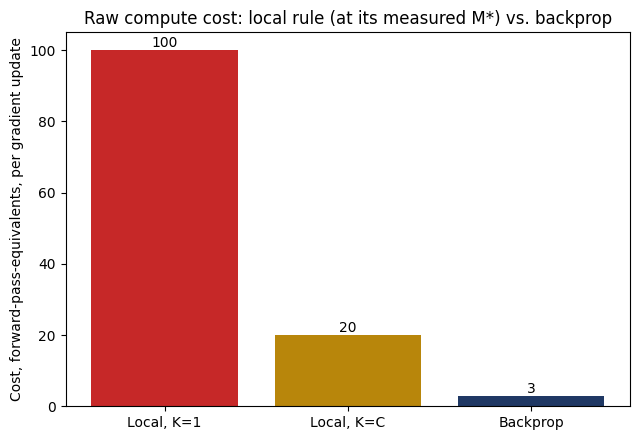

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
names = ['Local, K=1', 'Local, K=C', 'Backprop']
costs = [cost_k1, cost_kc, backprop_cost]
colors = ['#C62828', '#B8860B', '#1F3864']
bars = ax.bar(names, [c if c is not None else 0 for c in costs], color=colors)
ax.set_ylabel('Cost, forward-pass-equivalents, per gradient update')
ax.set_title('Raw compute cost: local rule (at its measured M*) vs. backprop')
for bar, c in zip(bars, costs):
    label = f'{c:.0f}' if c is not None else 'not reached'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), label, ha='center', va='bottom')
plt.tight_layout()
plt.show()

## How to read this result

**If K=C's cost comes out higher than backprop's** (plausible, and consistent with your program's own Phase V finding that the local-rule family does not win on raw accuracy/speed against every alternative): that is not a failure of this experiment, and it does not undo anything confirmed so far. It answers a specific, narrow question — raw FLOPs for one gradient update — that is only one part of the full cost picture. Two things stay true regardless of this number:

1. **Memory.** Backprop's activation tape grows with model depth; the probe-based local rule needs no such tape. This was already established in prior work (roughly 40x+ memory reduction at meaningful depth) and does not depend on this notebook's FLOPs comparison at all.
2. **Parallelism.** All M probes in a single gradient estimate are *embarrassingly parallel* — they can run simultaneously across many devices or cores with no sequential dependency, unlike backprop's inherently sequential backward pass. A FLOPs comparison doesn't capture this; a wall-clock comparison on real parallel hardware could look very different from the raw-FLOPs number above.

**The honest, complete framing**, matching how your own program has framed every other result in this line of work: the local rule is not a drop-in cheaper replacement for backprop's raw compute cost on this kind of task. Its case is about where backprop is *structurally unavailable or costly in ways FLOPs don't measure* — no differentiable pipeline, no room for an activation tape, or a need for massive forward-pass parallelism — not about beating it head-to-head on FLOPs for an ordinary differentiable regression task like this one.

**Also worth checking:** does K=C's advantage over K=1 (the M* ratio) match the roughly 5x you'd expect from the barrier law's prediction that per-channel feedback should need dramatically fewer samples than a global scalar, given the architecture's confirmed S=1 coupling scope? If it's close to that, it's a second independent confirmation of the barrier law itself, on top of everything else confirmed so far.

## Next steps

1. **Re-run this on the real regression/denoising task** your Bridge 3 theorem targets (the Wiener-gain setup), rather than this notebook's synthetic linear-regression stand-in, to get an M* number that's directly citable in the paper.
2. **Try larger C** (more modes) to see whether K=C's advantage over K=1 grows with model size, as the barrier law predicts it should (K=1's M* should scale with the coupling scope S; K=C's should stay flat).
3. **If wall-clock/parallel-hardware timing matters for your final claim**, this notebook's FLOPs comparison is a necessary but not sufficient step — an actual multi-core or multi-GPU wall-clock benchmark of batched probe evaluation vs. backprop would be the next, more expensive but more decisive experiment.